# Performance eval, results, and plotting

All experiments ran with fixed beta=2.0, tested at different degrees of misspecification and sample sizes

1. Ricker NPE
2. Ricker ABC
3. Plotting

In [8]:
import sys
sys.path.append('../')
import utils.metrics as metrics
import numpy as np
import torch
import io
import pickle
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import norm, qmc
from scipy import stats as stats
from simulators.oup import oup
from simulators.ricker import ricker
from simulators.turin import turin
from utils.metrics import RMSE

import warnings
warnings.filterwarnings('ignore')
        
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [7]:
# Utility functions

class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else: return super().find_class(module, name)

def load_models(root_name: str, device: torch.device):
    sum_net = torch.load("{root_name}/sum_net.pkl".format(root_name=root_name), map_location=device)

    density_estimator = torch.load("{root_name}/density_estimator.pkl".format(root_name=root_name), map_location=device)

    with open("{root_name}/posterior.pkl".format(root_name=root_name), "rb") as handle:
        posterior = CPU_Unpickler(handle).load() if device == torch.device('cpu') else pickle.load(handle)
    
    return sum_net, density_estimator, posterior


def read_rnpe(model="oup", var=1.0, degree=0, seed=1, theta=[0.5,1.0]):
    file = f"seed={seed}_degree={degree if float(degree)!=0 else 0}_var={var}_theta={theta}_{model}"

    results_dir = f"../objects/RNPE/{model}_final"
    fn = f"{results_dir}/{file}.pickle"

    with open(fn, "rb") as f:
        results = pickle.load(f)

    return np.array(results['posterior_samples']['RNPE'])


def sample_posteriors(posterior, obs, num):
    return posterior.sample((num,), x=obs.reshape(1, 1, 100, -1), show_progress_bars=False)


def temporalMomentsGeneral(Y, K=3, B=4e9):
    N, Ns = Y.shape
    tau = np.linspace(0, 100, Ns)
    out = np.zeros((N, K))
    Y = Y.detach().numpy()
    for k in range(K):
        for i in range(N):
            out[i, k] = np.trapz(tau**(k) * Y[i], tau) + 1e-4
    return np.log(out)


def generate_u(N, timesteps, engine=None):
    """
    Generates a (N, T) block of noise.
    If engine is provided, it draws the next sequence in the Sobol chain.
    """
    if engine is not None:
        u_uniform = engine.random(N)
        # Map [0, 1] to [0.0001, 0.9999]
        # This keeps Gaussian noise within approx +/- 3.7 standard deviations
        u_safe = 1e-4 + (u_uniform * (1 - 2e-4))
        return torch.tensor(stats.norm.ppf(u_safe), dtype=torch.float32, device=device)
    else:
        return torch.randn(N, timesteps).to(device)

## Shared parameters

In [9]:
beta = 2.0
degrees = [0, 0.1, 0.2]
sample_sizes = [256, 128, 32]
n_realizations = 128
n_reruns = 5
t_ricker = 100

theta_gt = torch.tensor([4., 10.])

# Define ricker simulator
sim_N = 1

qmc_engine = qmc.Sobol(d=t_ricker, scramble=True)

u = generate_u(sim_N, t_ricker)
u_qmc = generate_u(sim_N, t_ricker, qmc_engine)

simulator = ricker(u, sim_N)
simulator_qmc = ricker(u_qmc, sim_N)

## 1. Ricker NPE

In [ ]:
n_samples_npe = 1024


### 1.1 RMSE on NPE

### 1.2 MMD on NPE

## 2. Ricker ABC

## 3. Plotting

### Define general function for plotting posterior joint distributions

In [3]:
def plot_posterior_joints(post_normal, post_robust, post_efficient, *, method_label="NPE", height=5):
      theta_gt = [4, 10]

      graph = sns.jointplot(x=post_normal[:, 0], y=post_normal[:, 1],
            cmap="Oranges", kind="kde", height=height, marginal_kws={"color":"C1", "alpha":.5, "shade":True}, shade=True, thresh=0.05, alpha=.5,
            label=method_label) 

      # plot joint with robust

      graph.x = post_robust[:, 0]
      graph.y = post_robust[:, 1]
      graph.plot_joint(sns.kdeplot, cmap="Blues", shade=True, alpha=.5, label='Robust')
      graph.ax_joint.axvline(x=theta_gt[0], lw=1, ls="-",c="black", label="True $\\theta$")
      graph.ax_joint.axhline(y=theta_gt[1], lw=1, ls="-",c="black")
      graph.plot_marginals(sns.kdeplot, color='C0', shade=True, alpha=.5, legend=False)

      # plot joint with robust-efficient

      graph.x = post_efficient[:, 0]
      graph.y = post_efficient[:, 1]
      graph.plot_joint(sns.kdeplot, cmap="Greens", shade=True, alpha=.5, label='Ours')
      graph.ax_joint.axvline(x=theta_gt[0], lw=1, ls="-",c="black", label="True $\\theta$")
      graph.ax_joint.axhline(y=theta_gt[1], lw=1, ls="-",c="black")
      graph.plot_marginals(sns.kdeplot, color='C2', shade=True, alpha=.5, legend=False)

      graph.ax_joint.axvline(x=2, ls="--", lw=1, c="gray", alpha=0.3)
      graph.ax_joint.axvline(x=8, ls="--", lw=1, c="gray", alpha=0.3)

      graph.ax_joint.axhline(y=0, ls="--", lw=1,c="gray", alpha=0.3)
      graph.ax_joint.axhline(y=20, ls="--", lw=1, c="gray", alpha=0.3)

      from matplotlib.patches import Patch
      from matplotlib.lines import Line2D

      legend_elements = [Line2D([0], [0], color='k', lw=1, label='True $\\theta$'),
            Patch(facecolor='C2', edgecolor='C2',
                  label='Ours'),
            Patch(facecolor='C0', edgecolor='C0',
                  label='Robust'),
            Patch(facecolor='C1', edgecolor='C1',
                  label=method_label)]

      graph.ax_joint.legend(handles=legend_elements, loc='upper right', fontsize=13) 

      graph.ax_joint.set_xlabel('$\\theta_1$')
      graph.ax_joint.set_ylabel('$\\theta_2$')

      plt.tight_layout()
      plt.show()

### Test plotting

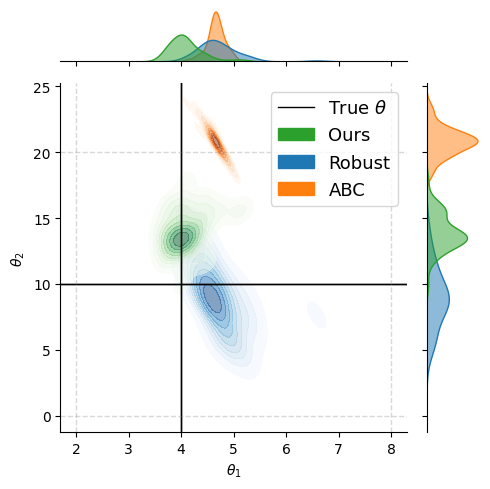

In [ ]:
target_degree = 0.2
target_beta = 2
ss = 32
i = 7

posterior_normal = np.load(f"../objects/ABC/ricker_consolidated/degree={target_degree}/lambda={target_beta}/sample_size={ss}/{i}/posterior_normal.npy")
posterior_robust = np.load(f"../objects/ABC/ricker_consolidated/degree={target_degree}/lambda={target_beta}/sample_size={ss}/{i}/posterior_robust.npy")
posterior_robust_efficient = np.load(f"../objects/ABC/ricker_consolidated/degree={target_degree}/lambda={target_beta}/sample_size={ss}/{i}/posterior_efficient.npy")

plot_posterior_joints(posterior_normal, posterior_robust, posterior_robust_efficient, method_label="ABC", height=5)